# Logistic regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import pandas as pd

In [2]:
data = pd.read_csv('../../data/earthquake.txt', sep=' ')
data.head()

,popn,body,surface
0,equake,5.60,4.25
1,equake,5.18,3.93
2,equake,6.31,6.30
3,equake,5.36,4.49
4,equake,5.96,6.39


In [3]:
explosions = data[data.popn == 'explosn']
earthquakes = data[data.popn == 'equake']

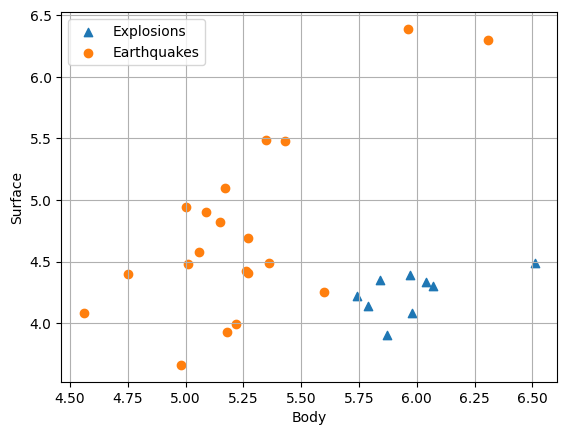

In [4]:
plt.scatter(explosions.body, explosions.surface, marker='^', label='Explosions')
plt.scatter(earthquakes.body, earthquakes.surface, marker='o', label='Earthquakes')
plt.legend()
plt.xlabel("Body")
plt.ylabel("Surface")
plt.grid()
plt.show()

In [5]:
X = data[['body', 'surface']]
y = data['popn'].apply(lambda item: 0 if item == 'equake' else 1)

### Logistic regression without regularization

In [6]:
logit_plain = sklearn.linear_model.LogisticRegression(C=np.inf)
logit_plain.fit(X=X, y=y)

C:\Users\muric\Desktop\Universities\WUT_MASTERS\AML\labs\task1\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",inf
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [7]:
print(f'Intercept: {logit_plain.intercept_}, Coeficients: {logit_plain.coef_}')
y_proba = logit_plain.predict_proba(X)
print(f'Probabilities: \n{y_proba}')
print(f'Log-likelyhood: {np.sum(y * np.log(y_proba[:,1]) + (1 - y) * np.log(y_proba[:,0]))}')

Intercept: [-135.04765908], Coeficients: [[ 111.91608035 -117.54515973]]
Probabilities: 
[[9.99623621e-01 3.76378816e-04]
 [9.99999969e-01 3.14508242e-08]
 [1.00000000e+00 2.71719066e-74]
 [1.00000000e+00 4.55919924e-28]
 [1.00000000e+00 6.73136569e-96]
 [1.00000000e+00 2.35439841e-29]
 [1.00000000e+00 1.92311837e-68]
 [1.00000000e+00 4.02300724e-53]
 [1.00000000e+00 1.32931825e-79]
 [1.00000000e+00 1.43811319e-44]
 [1.00000000e+00 2.33570214e-28]
 [1.00000000e+00 1.18751053e-42]
 [9.99637043e-01 3.62956858e-04]
 [9.99999998e-01 2.39254786e-09]
 [1.00000000e+00 3.04157444e-47]
 [1.00000000e+00 4.03167927e-62]
 [1.00000000e+00 4.03362280e-55]
 [1.00000000e+00 5.07501707e-46]
 [1.00000000e+00 1.54564287e-68]
 [1.00000000e+00 3.33030492e-75]
 [1.33226763e-14 1.00000000e+00]
 [3.86743434e-08 9.99999961e-01]
 [7.30679033e-04 9.99269321e-01]
 [3.74922315e-12 1.00000000e+00]
 [0.00000000e+00 1.00000000e+00]
 [0.00000000e+00 1.00000000e+00]
 [1.22488279e-05 9.99987751e-01]
 [0.00000000e+00 1.0

C:\Users\muric\AppData\Local\Temp\ipykernel_22876\4184138367.py:4: RuntimeWarning: divide by zero encountered in log
  print(f'Log-likelyhood: {np.sum(y * np.log(y_proba[:,1]) + (1 - y) * np.log(y_proba[:,0]))}')


### Logistic regression with L2 regularization

In [8]:
logit_regularization = sklearn.linear_model.LogisticRegression(l1_ratio=0)
logit_regularization.fit(X=X, y=y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [9]:
print(f'Intercept: {logit_regularization.intercept_}, Coeficients: {logit_regularization.coef_}')
y_proba = logit_regularization.predict_proba(X)
print(f'Probabilities: \n{y_proba}')
print(f'Log-likelyhood: {np.sum(y * np.log(y_proba[:,1]) + (1 - y) * np.log(y_proba[:,0]))}')

Intercept: [-7.46937734], Coeficients: [[ 2.16922885 -1.18171354]]
Probabilities: 
[[0.58515658 0.41484342]
 [0.70618068 0.29381932]
 [0.7731771  0.2268229 ]
 [0.75918281 0.24081719]
 [0.89011564 0.10988436]
 [0.78285929 0.21714071]
 [0.90730829 0.09269171]
 [0.91412542 0.08587458]
 [0.91306214 0.08693786]
 [0.8693947  0.1306053 ]
 [0.77710904 0.22289096]
 [0.82917305 0.17082695]
 [0.72942144 0.27057856]
 [0.70287784 0.29712216]
 [0.87049329 0.12950671]
 [0.90188961 0.09811039]
 [0.88013487 0.11986513]
 [0.9167575  0.0832425 ]
 [0.92135475 0.07864525]
 [0.89717799 0.10282201]
 [0.37380085 0.62619915]
 [0.4272215  0.5727785 ]
 [0.48538785 0.51461215]
 [0.45062057 0.54937943]
 [0.34179322 0.65820678]
 [0.20645813 0.79354187]
 [0.50120871 0.49879129]
 [0.33598908 0.66401092]
 [0.35058391 0.64941609]]
Log-likelyhood: -8.425076253244171


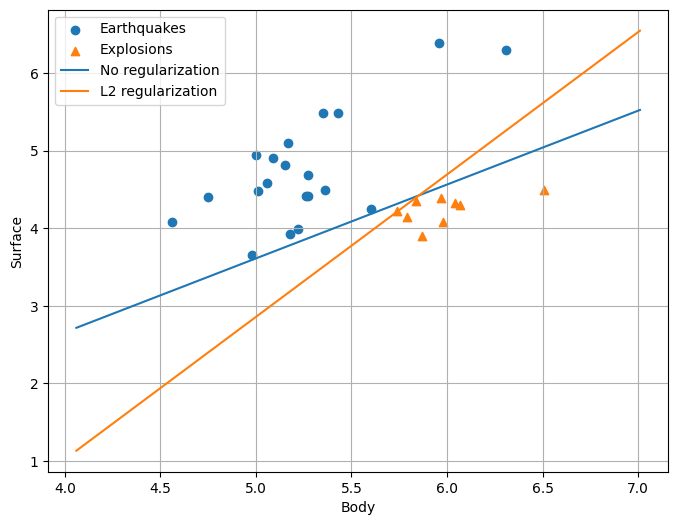

In [10]:
def plot_boundary_from_coef(classifier, X, label, ax):
    b0 = classifier.intercept_[0]
    b1 = classifier.coef_[0][0]
    b2 = classifier.coef_[0][1]

    x1 = np.linspace(X['body'].min() - 0.5, X['body'].max() + 0.5, 100)
    x2 = -(b0 + b1 * x1) / b2

    ax.plot(x1, x2, label=label)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(earthquakes.body, earthquakes.surface, marker='o', label='Earthquakes')
ax.scatter(explosions.body, explosions.surface, marker='^', label='Explosions')
plot_boundary_from_coef(logit_plain, X, 'No regularization', ax)
plot_boundary_from_coef(logit_regularization, X, 'L2 regularization', ax)
ax.set_xlabel('Body')
ax.set_ylabel('Surface')
ax.legend()
ax.grid()
plt.show()

### Comments: 

The moodel with the Ridge L2 regularization has smaller coeficients (Intercept: [-7.46937734], Coeficients: [[ 2.16922885 -1.18171354]]) vs Intercept: [-135.04765908], Coeficients: [[ 111.91608035 -117.54515973]].

Since our data is linearly separable classes - logistic regression without this modification doesn't converge properly, since therre exist multiple solutions and it cannot select the best one.


## Part 2

In [11]:
b = np.array([0.5, 1, 1, 1, 1, 1])

In [12]:
def generate_data(n = 50):
    X = np.random.normal(loc=0, scale=1, size=(n, 5))
    probability = 1 / (1+np.exp(-(X @ b[1:] + b[0])))
    y = np.random.binomial(n=1, p=probability)
    return X, y

In [13]:
def calculateMSE(n = 50):
    MSEs = []
    for i in range(0,100):
        X, y = generate_data(n)
        logit = sklearn.linear_model.LogisticRegression()
        logit.fit(X, y)
        estimated_parameters = np.concatenate(([logit.intercept_,logit.coef_.flatten()]))
        MSEs.append(np.sum((estimated_parameters - b)**2))
    
    MSE_avg = sum(MSEs)/len(MSEs)
    return MSE_avg

MSE_avg = calculateMSE(50)
print(f'Estimated MSE: {MSE_avg}')

Estimated MSE: 0.8491340292240992


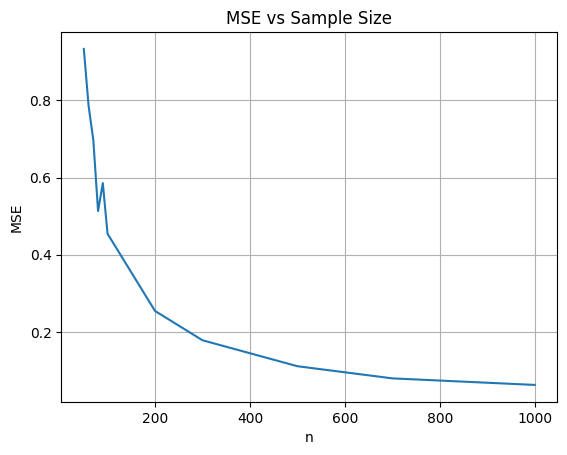

In [14]:
x = [50,60,70,80,90,100,200,300, 500, 700 ,1000]
y = list(map(calculateMSE, x))
plt.plot(x, y)
plt.xlabel('n')
plt.ylabel('MSE')
plt.title('MSE vs Sample Size')
plt.grid()
plt.show()

In [15]:
def calculateMSEmisspecifiedModel(n = 50):
    MSEs = []
    for i in range(0,100):
        X, y = generate_data(n)
        logit = sklearn.linear_model.LogisticRegression()
        logit.fit(X[:, 0:3], y)
        estimated_parameters = np.concatenate(([logit.intercept_,logit.coef_.flatten()]))
        MSEs.append(np.sum((estimated_parameters - b[0:4])**2))
    
    MSE_avg = sum(MSEs)/len(MSEs)
    return MSE_avg

MSE_avg = calculateMSEmisspecifiedModel(50)
print(f'Estimated MSE: {MSE_avg}')

Estimated MSE: 0.7365455671253991


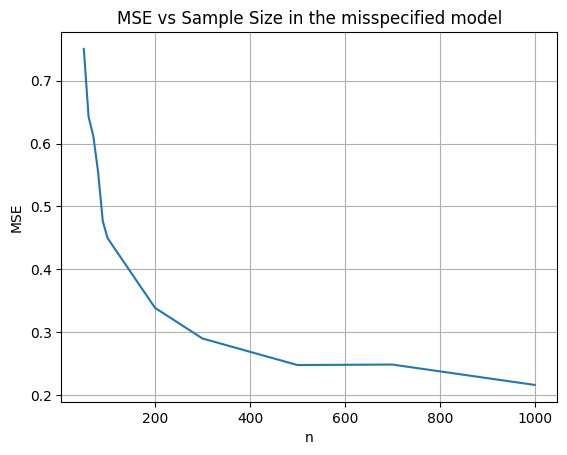

In [16]:
x = [50,60,70,80,90,100,200,300, 500, 700 ,1000]
y = list(map(calculateMSEmisspecifiedModel, x))
plt.plot(x, y)
plt.xlabel('n')
plt.ylabel('MSE')
plt.title('MSE vs Sample Size in the misspecified model')
plt.grid()
plt.show()

### Comments: 

The misspecified model which uses only 3 coeficients instead of 5 has poorer performance even with the larger dataset sizes and the normal one.
It is visisble that the curve reaches its plateauat the level of aroun 0.25 MSE. Meanwhile the normal model was able to reach level below 0.1 MSE 